🚀 ENSEMBLE FOOD DETECTOR - FIXED VERSION
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Checking models in Google Drive...
total 110090
-rw------- 1 root root 22546410 Mar  2 20:43 srilankan_food_model_74.5.pt
-rw------- 1 root root 22546410 Mar  2 20:43 srilankan_food_model_v21_74.5.pt
-rw------- 1 root root 22546410 Mar  6 19:53 srilankan_food_model_v22_71.3.pt
-rw------- 1 root root 22546410 Mar  8 10:20 srilankan_food_model_v23_70.1.pt
-rw------- 1 root root 22546410 Mar  8 14:26 srilankan_food_model_v24_71.9.pt

LOADING MODELS FROM GOOGLE DRIVE
📥 Loading model 1: srilankan_food_model_v21_74.5.pt
📥 Loading model 2: srilankan_food_model_v22_71.3.pt
📥 Loading model 3: srilankan_food_model_v24_71.9.pt

✅ Loaded 3 models!

UPLOAD TEST IMAGES
Please upload food images to test:


Saving n12.jpg to n12.jpg
Saving n13.jpg to n13.jpg

✅ Uploaded 2 images

TESTING ENSEMBLE DETECTOR

📸 Image: n12.jpg

🔍 DEBUG - Raw model outputs:

image 1/1 /content/test_images/n12.jpg: 640x608 (no detections), 600.4ms
Speed: 5.5ms preprocess, 600.4ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 608)

Model 1 (srilankan_food_model_v21_74.5.pt):

image 1/1 /content/test_images/n12.jpg: 640x608 1 Sausage Hotdog, 582.8ms
Speed: 3.2ms preprocess, 582.8ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 608)

Model 2 (srilankan_food_model_v22_71.3.pt):
   Class ID: 29 -> Sausage Hotdog (conf: 0.271)

image 1/1 /content/test_images/n12.jpg: 640x608 2 Hopperss, 1 Lunu sambol, 601.3ms
Speed: 3.2ms preprocess, 601.3ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 608)

Model 3 (srilankan_food_model_v24_71.9.pt):
   Class ID: 15 -> Hoppers (conf: 0.776)
   Class ID: 18 -> Lunu sambol (conf: 0.678)
   Class ID: 15 -> Hoppers (conf: 0.576)

📊 Individual M

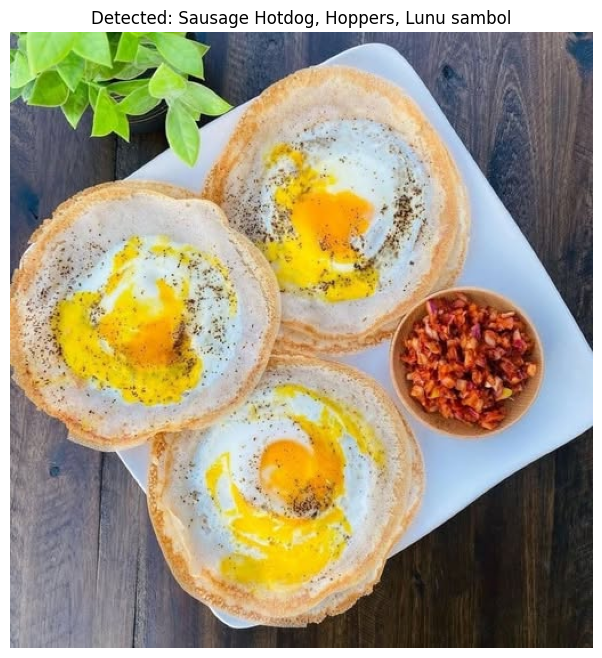


image 1/1 /content/test_images/n13.jpg: 384x640 1 Pol Sambol, 1 Sausage Hotdog, 407.7ms
Speed: 4.9ms preprocess, 407.7ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/test_images/n13.jpg: 384x640 1 Sausage Hotdog, 402.6ms
Speed: 3.6ms preprocess, 402.6ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/test_images/n13.jpg: 384x640 1 Hoppers, 1 Lunu sambol, 379.6ms
Speed: 3.9ms preprocess, 379.6ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)


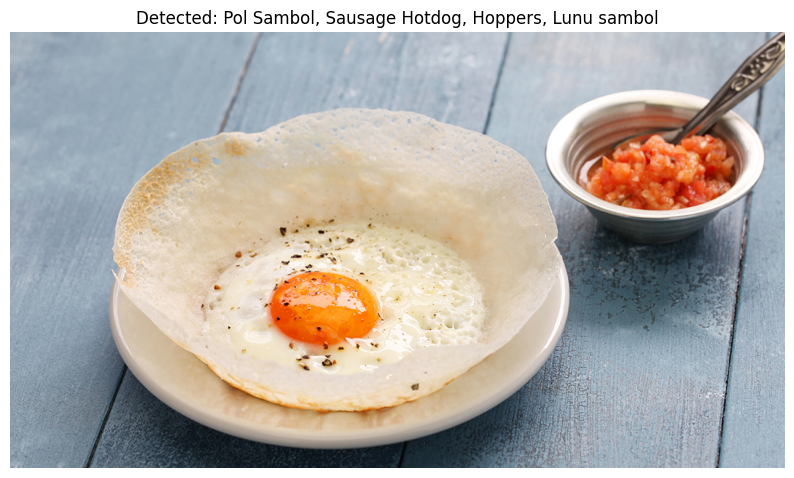


TEST V24 MODEL ALONE (for comparison)

📸 n12.jpg

image 1/1 /content/test_images/n12.jpg: 640x608 2 Hopperss, 1 Lunu sambol, 903.8ms
Speed: 5.7ms preprocess, 903.8ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 608)
   V24 alone: ['Hoppers', 'Lunu sambol', 'Hoppers']

📸 n13.jpg

image 1/1 /content/test_images/n13.jpg: 384x640 1 Hoppers, 1 Lunu sambol, 571.9ms
Speed: 5.7ms preprocess, 571.9ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)
   V24 alone: ['Hoppers', 'Lunu sambol']


In [14]:


# INSTALL ULTRALYTICS
!pip install ultralytics --quiet

print("="*60)
print("🚀 ENSEMBLE FOOD DETECTOR - FIXED VERSION")
print("="*60)

# MOUNT GOOGLE DRIVE
from google.colab import drive
drive.mount('/content/drive')

# IMPORT LIBRARIES
from ultralytics import YOLO
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import cv2
import os
from google.colab import files

print("\nChecking models in Google Drive...")
!ls -la /content/drive/MyDrive/TeamProject/models/

class EnsembleFoodDetector:
    """Fixed version - uses model's own class names to avoid mapping errors"""

    def __init__(self, model_paths):
        self.models = []
        self.model_names = []

        for i, path in enumerate(model_paths):
            print(f"📥 Loading model {i+1}: {path.split('/')[-1]}")
            model = YOLO(path)
            self.models.append(model)
            self.model_names.append(path.split('/')[-1])

        print(f"\n✅ Loaded {len(self.models)} models!")

    def detect_average(self, image_path, confidence=0.25):
        """Average confidence from both models - uses model's own class names"""
        all_predictions = []

        for i, model in enumerate(self.models):
            results = model(image_path, conf=confidence)[0]
            for box in results.boxes:
                class_id = int(box.cls[0])
                # IMPORTANT: Use model's own class names
                class_name = results.names[class_id]
                conf = float(box.conf[0])
                all_predictions.append({
                    'class_name': class_name,
                    'confidence': conf,
                    'model': i
                })

        # Group by class name and average confidence
        class_groups = {}
        for pred in all_predictions:
            key = pred['class_name']
            if key not in class_groups:
                class_groups[key] = []
            class_groups[key].append(pred['confidence'])

        # Calculate averages
        results = []
        for class_name, confs in class_groups.items():
            avg_conf = np.mean(confs)
            if avg_conf >= confidence:
                results.append({
                    'class_name': class_name,
                    'confidence': round(avg_conf, 3),
                    'method': 'average'
                })

        return results

    def detect_voting(self, image_path, min_votes=2, confidence=0.25):
        """Food must be detected by multiple models"""
        all_votes = []

        for model in self.models:
            results = model(image_path, conf=confidence)[0]
            for box in results.boxes:
                class_name = results.names[int(box.cls[0])]
                all_votes.append(class_name)

        # Count votes
        vote_count = Counter(all_votes)

        # Keep foods with enough votes
        results = []
        for class_name, votes in vote_count.items():
            if votes >= min_votes:
                results.append({
                    'class_name': class_name,
                    'votes': votes,
                    'method': 'voting'
                })

        return results

    def quick_detect(self, image_path):
        """Simple detection - returns just food names"""
        results = self.detect_average(image_path)
        return [r['class_name'] for r in results]

    def debug_detection(self, image_path):
        """Debug function to see what each model detects"""
        print("\n🔍 DEBUG - Raw model outputs:")
        for i, model in enumerate(self.models):
            results = model(image_path)[0]
            print(f"\nModel {i+1} ({self.model_names[i]}):")
            for box in results.boxes:
                class_id = int(box.cls[0])
                class_name = results.names[class_id]
                confidence = float(box.conf[0])
                print(f"   Class ID: {class_id} -> {class_name} (conf: {confidence:.3f})")

# ============================================================
# LOAD MODELS - CHOOSE WHICH ONES TO USE
# ============================================================
print("\n" + "="*60)
print("LOADING MODELS FROM GOOGLE DRIVE")
print("="*60)

# Define which models to use - you can comment/uncomment as needed
model_paths = [
    "/content/drive/MyDrive/TeamProject/models/srilankan_food_model_v21_74.5.pt",
    "/content/drive/MyDrive/TeamProject/models/srilankan_food_model_v22_71.3.pt",
    #"/content/drive/MyDrive/TeamProject/models/srilankan_food_model_v23_70.1.pt",
    "/content/drive/MyDrive/TeamProject/models/srilankan_food_model_v24_71.9.pt"
]

# Create ensemble detector
ensemble = EnsembleFoodDetector(model_paths)

# ============================================================
# UPLOAD AND TEST IMAGES
# ============================================================
print("\n" + "="*60)
print("UPLOAD TEST IMAGES")
print("="*60)
print("Please upload food images to test:")
uploaded = files.upload()

# Save uploaded files
!mkdir -p test_images
image_paths = []
for filename in uploaded.keys():
    # Clean filename
    safe_filename = filename.replace(" ", "_")
    save_path = f"test_images/{safe_filename}"
    with open(save_path, 'wb') as f:
        f.write(uploaded[filename])
    image_paths.append(save_path)

print(f"\n✅ Uploaded {len(image_paths)} images")

# ============================================================
# TEST ON UPLOADED IMAGES
# ============================================================
print("\n" + "="*60)
print("TESTING ENSEMBLE DETECTOR")
print("="*60)

for img_path in image_paths:
    print(f"\n{'='*50}")
    print(f"📸 Image: {os.path.basename(img_path)}")
    print(f"{'='*50}")

    # DEBUG - Show raw model outputs first
    ensemble.debug_detection(img_path)

    # Test individual models
    print("\n📊 Individual Model Detections:")
    for i, model in enumerate(ensemble.models):
        results = model(img_path)[0]
        foods = [results.names[int(box.cls[0])] for box in results.boxes]
        print(f"   Model {i+1}: {foods if foods else 'No foods detected'}")

    # Test ensemble methods
    print("\n🔹 Ensemble Methods:")

    # Method 1: Average
    avg_results = ensemble.detect_average(img_path)
    print(f"   Average: {[r['class_name'] for r in avg_results]}")

    # Method 2: Voting (need 2+ models to agree)
    vote_results = ensemble.detect_voting(img_path, min_votes=2)
    print(f"   Voting (2+): {[r['class_name'] for r in vote_results]}")

    # Method 3: Voting (need 3+ models to agree)
    vote3_results = ensemble.detect_voting(img_path, min_votes=3)
    print(f"   Voting (3+): {[r['class_name'] for r in vote3_results]}")

    # Final quick detection
    foods = ensemble.quick_detect(img_path)
    print(f"\n✅ FINAL DETECTION: {foods}")

# ============================================================
# SHOW DETECTION ON IMAGE
# ============================================================
print("\n" + "="*60)
print("SHOW DETECTION ON IMAGE")
print("="*60)

for img_path in image_paths:
    # Get ensemble results
    foods = ensemble.quick_detect(img_path)

    # Load and display image
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 8))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Detected: {', '.join(foods) if foods else 'No foods'}")
    plt.show()

# ============================================================
# TEST SINGLE MODEL (V24 alone) for comparison
# ============================================================
print("\n" + "="*60)
print("TEST V24 MODEL ALONE (for comparison)")
print("="*60)

v24_model = YOLO("/content/drive/MyDrive/TeamProject/models/srilankan_food_model_v24_71.9.pt")

for img_path in image_paths:
    print(f"\n📸 {os.path.basename(img_path)}")
    results = v24_model(img_path)[0]
    foods = [results.names[int(box.cls[0])] for box in results.boxes]
    print(f"   V24 alone: {foods}")